In [1]:
source("init/init_library.R")
source("init/init_font.R")

init_library()
init_font()

source("init/constants.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


here() starts at /home/sand94/projects/VReGTrET/GraphTheory_ET_VR_Westbrueck/Analysis/raw_gaze_analysis

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Welcome to emmeans.
Caution: You lose important infor

In [2]:
df <- read_csv(here(DATA_FOLDER, "median_io_group_gaze.csv"))
df <- df |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        PID = factor(PID)
    ) |>
    rename(
        building_location = inside,
        group = category
    )

Rows: 1829 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (4): PID, inside, GroupCount, median_clusterDuration

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
model <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, Gamma(link = "inverse"))

In [6]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)

# View results
summary(emm)


,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,central,0.4004916,0.01403735,Inf,0.3729789,0.4280043
2,control,0.4331715,0.01687316,Inf,0.4001007,0.4662423
3,peripheral,0.4982905,0.02314886,Inf,0.4529195,0.5436614


In [7]:
# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)
# View results
summary(emm)



,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4089795,0.01269408,Inf,0.3840996,0.4338594
2,inside,0.4789896,0.02165684,Inf,0.4365429,0.5214362


In [9]:
df_node <- read_csv(here(DATA_FOLDER, "io_node_group_gaze.csv"))

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        building = hitObjectColliderName,
        duration = clusterDuration
    )


Rows: 17925 Columns: 8


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [15]:
df_group_node <- df_node |>
    group_by(PID, building, group, building_location, connections) |>
    summarise(median_duration = median(duration)) |>
    ungroup()

`summarise()` has grouped output by 'PID', 'building', 'group',
'building_location'. You can override using the `.groups` argument.


In [11]:
df <- read_csv(here(DATA_FOLDER, "graph_group_connections.csv"))
df <- df |> 
    mutate(
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control")),
        hitObjectColliderName = factor(hitObjectColliderName)
    ) |>
    rename(
        group = category
    )

Rows: 1826 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (2): PID, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [16]:
df_rm_null <- df_group_node |> filter(connections > 0)

model <- glmer(connections ~  group + building_location + (1 | PID), data = df_rm_null, Gamma(link = "inverse"))

In [17]:
# Create a reference grid
ref_grid <- ref_grid(model)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)

# View results
summary(emm)

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,peripheral,5.119276,0.4476219,Inf,4.241953,5.996599
2,central,5.382336,0.4911143,Inf,4.419769,6.344902
3,control,6.355806,0.7004506,Inf,4.982949,7.728664


#### EMM Node and Dwell Time
**TODO**
**CONTINUE FROM HERE**

In [23]:
df_node <- read_csv("io_node_group_gaze.csv")

df_node <- df_node |> 
    mutate(
        inside = factor(inside),
        inside = fct_recode(inside, "outside" = "0", "inside" = "1"),
        hitObjectColliderName = factor(hitObjectColliderName),
        PID = factor(PID),
        category = factor(category, levels = c("peripheral", "central", "control"))
    ) |>
    rename(
        building_location = inside,
        group = category,
        duration = clusterDuration
    ) |>
    group_by(PID, group, hitObjectColliderName, building_location) |>
    summarize(
        mean_connections = mean(connections)
    ) |>
    ungroup() |>
    filter(mean_connections > 0)

Rows: 17925 Columns: 8
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): hitObjectColliderName, category
dbl (6): clusterID, sampleNr, clusterDuration, PID, inside, connections

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
`summarise()` has grouped output by 'PID', 'group', 'hitObjectColliderName'.
You can override using the `.groups` argument.


In [24]:
df_node <- df_node %>% 
    mutate(
        group = factor(group, c("control", "peripheral", "central"))
    )

In [25]:
df %>% names()

[1] "PID"                   "hitObjectColliderName" "connections"          
[4] "group"

In [40]:
model_0 <- glmer(median_clusterDuration ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
model_inter <- glmer(median_clusterDuration ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))
df <- df %>% 
    mutate(
        group = factor(group, c("control", "peripheral", "central"))
    )
model_full <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))

In [41]:
node_model_0 <- glmer(mean_connections ~ 1 + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
node_model_inter <- glmer(mean_connections ~ building_location + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())

node_model_full <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = poisson())
     

In [42]:
# Create a reference grid
ref_grid <- ref_grid(model_full)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_building <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(model_full, ~ group)
emm_building_eff <- emmeans(model_full, ~ building_location)

VarCorr(model_full)
full_var <- as_tibble(VarCorr(model_full)) %>% pull(sdcor)
full_sd <- sqrt(sum(full_var^2))
eff_size(emm_eff, sigma = full_sd, edf = 1822)

# View results
summary(emm, level = 0.95)
emm_table_pairs <- pairs(emm, adjust = "tukey") %>% summary()
pairs(emm, adjust = "tukey")

summary(emm_building)
pairs(emm_building, adjust = "tukey")
r2_nakagawa(model_full)

 Groups                Name        Std.Dev.
 hitObjectColliderName (Intercept) 0.28454 
 PID                   (Intercept) 0.12020 
 Residual                          0.36876 

 contrast             effect.size    SE  df asymp.LCL asymp.UCL
 control - peripheral       0.623 0.198 Inf     0.234   1.01144
 control - central         -0.390 0.195 Inf    -0.771  -0.00782
 peripheral - central      -1.012 0.197 Inf    -1.399  -0.62566

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.481 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,control,0.4331712,0.01687345,Inf,0.4000999,0.4662426
2,peripheral,0.4982853,0.02314907,Inf,0.4529139,0.5436566
3,central,0.4004901,0.01403756,Inf,0.3729770,0.4280032


 contrast             estimate     SE  df z.ratio p.value
 control - peripheral  -0.0651 0.0216 Inf  -3.013  0.0073
 control - central      0.0327 0.0166 Inf   1.972  0.1191
 peripheral - central   0.0978 0.0210 Inf   4.646  <.0001

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 3 estimates 

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,0.4089780,0.01269419,Inf,0.3840978,0.4338581
2,inside,0.4789864,0.02165684,Inf,0.4365398,0.5214330


 contrast         estimate     SE  df z.ratio p.value
 outside - inside    -0.07 0.0207 Inf  -3.376  0.0007

Results are averaged over the levels of: group 

# R2 for Mixed Models

  Conditional R2: 0.549
     Marginal R2: 0.233

In [43]:
library(performance)
library(MASS)
library(patchwork)
library(ggprism)

In [44]:
df <- df %>% 
    mutate(
        group = factor(group, c("central", "control", "peripheral"))
    )
model_full_emm <- glmer(median_clusterDuration ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df, family = Gamma(link = "inverse"))


ref_grid_emm <- ref_grid(model_full_emm)
custom_emm_table <- emm_table_pairs %>%
    rename(p = p.value) %>%
    mutate(
        group1 = c("control", "control", "peripheral"),
        group2 = c("peripheral", "central", "central"),
        label = c("**", "P = 0.11", "***"),
        y.position = c(0.80, 0.75, 0.85)
    )


dwell_time_fig <- ref_grid_emm %>% emmip(~ group, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = median_clusterDuration, x = group, color = group), alpha = 0.2, data = df)+ 
  labs(
    title = "EMM(s) of Dwell Time",
    x = "Group",
    y = "Dwell Time (s)",
  ) +
  add_pvalue(custom_emm_table, tip.length = 0) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0,1), expand = c(0,0)) 


In [31]:
df_node <- df_node %>% 
    mutate(
        group = factor(group, c("control", "peripheral", "central"))
    )
node_model_full_emm <- glmer(mean_connections ~ building_location + group + (1 | PID) + (1 | hitObjectColliderName), data = df_node, family = Gamma(link = "inverse"))

In [45]:
node_ref_grid_emm <- ref_grid(node_model_full_emm)
ndc_mean_fig <- node_ref_grid_emm %>% emmip(~ group, CIs = TRUE, type = "response", style="factor") +
  geom_violin(aes(y = mean_connections, x = group, color = group), alpha = 0.2, data = df_node)+ 
  labs(
    title = "EMM(s) of NDC",
    x = "Group",
    y = "NDC"
  ) +
  scale_x_discrete(expand = c(0,.5)) +
  scale_y_continuous(lim = c(0, 20), expand = c(0,0))

In [46]:
# Create a reference grid
ref_grid <- ref_grid(node_model_full_emm)
# Regrid to transform the reference grid
# This is particularly useful for gamma models with inverse link
new_grid <- regrid(ref_grid, transform = "response")

# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ group)
emm_eff <- emmeans(node_model_full_emm, ~ group)
eff_size(emm_eff, sigma = sigma(node_model_full_emm)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(model)


 contrast             effect.size     SE  df asymp.LCL asymp.UCL
 control - peripheral     -0.0671 0.0385 Inf   -0.1426   0.00848
 control - central        -0.0438 0.0385 Inf   -0.1194   0.03172
 peripheral - central      0.0233 0.0378 Inf   -0.0508   0.09727

Results are averaged over the levels of: building_location 
sigma used for effect sizes: 0.6216 
Confidence level used: 0.95 

,group,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,control,4.371542,0.6515741,Inf,3.094480,5.648604
2,peripheral,3.606637,0.4098248,Inf,2.803395,4.409878
3,central,3.836454,0.4727079,Inf,2.909964,4.762945


 contrast             estimate    SE  df z.ratio p.value
 control - peripheral    0.765 0.502 Inf   1.523  0.2801
 control - central       0.535 0.504 Inf   1.062  0.5375
 peripheral - central   -0.230 0.379 Inf  -0.607  0.8163

Results are averaged over the levels of: building_location 
P value adjustment: tukey method for comparing a family of 3 estimates 

# R2 for Mixed Models

  Conditional R2: 0.008
     Marginal R2: 0.006

In [47]:
# Now use the transformed grid for emmeans
emm <- emmeans(new_grid, ~ building_location)
emm_eff <- emmeans(node_model_full_emm, ~ building_location)
eff_size(emm_eff, sigma = sigma(node_model_full_emm)*sqrt(2), edf = df.residual(model))

# View results
summary(emm)
pairs(emm, adjust = "tukey")
r2_nakagawa(model)

 contrast         effect.size     SE  df asymp.LCL asymp.UCL
 outside - inside       0.393 0.0515 Inf     0.292     0.494

Results are averaged over the levels of: group 
sigma used for effect sizes: 0.6216 
Confidence level used: 0.95 

,building_location,response,SE,df,asymp.LCL,asymp.UCL
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,outside,2.347045,0.1181908,Inf,2.115395,2.578695
2,inside,5.529377,0.8636556,Inf,3.836643,7.222111


 contrast         estimate    SE  df z.ratio p.value
 outside - inside    -3.18 0.849 Inf  -3.749  0.0002

Results are averaged over the levels of: group 

# R2 for Mixed Models

  Conditional R2: 0.008
     Marginal R2: 0.006

Warning message:
“Removed 55 rows containing non-finite outside the scale range
(`stat_ydensity()`).”
Warning message:
“Removed 7 rows containing non-finite outside the scale range
(`stat_ydensity()`).”


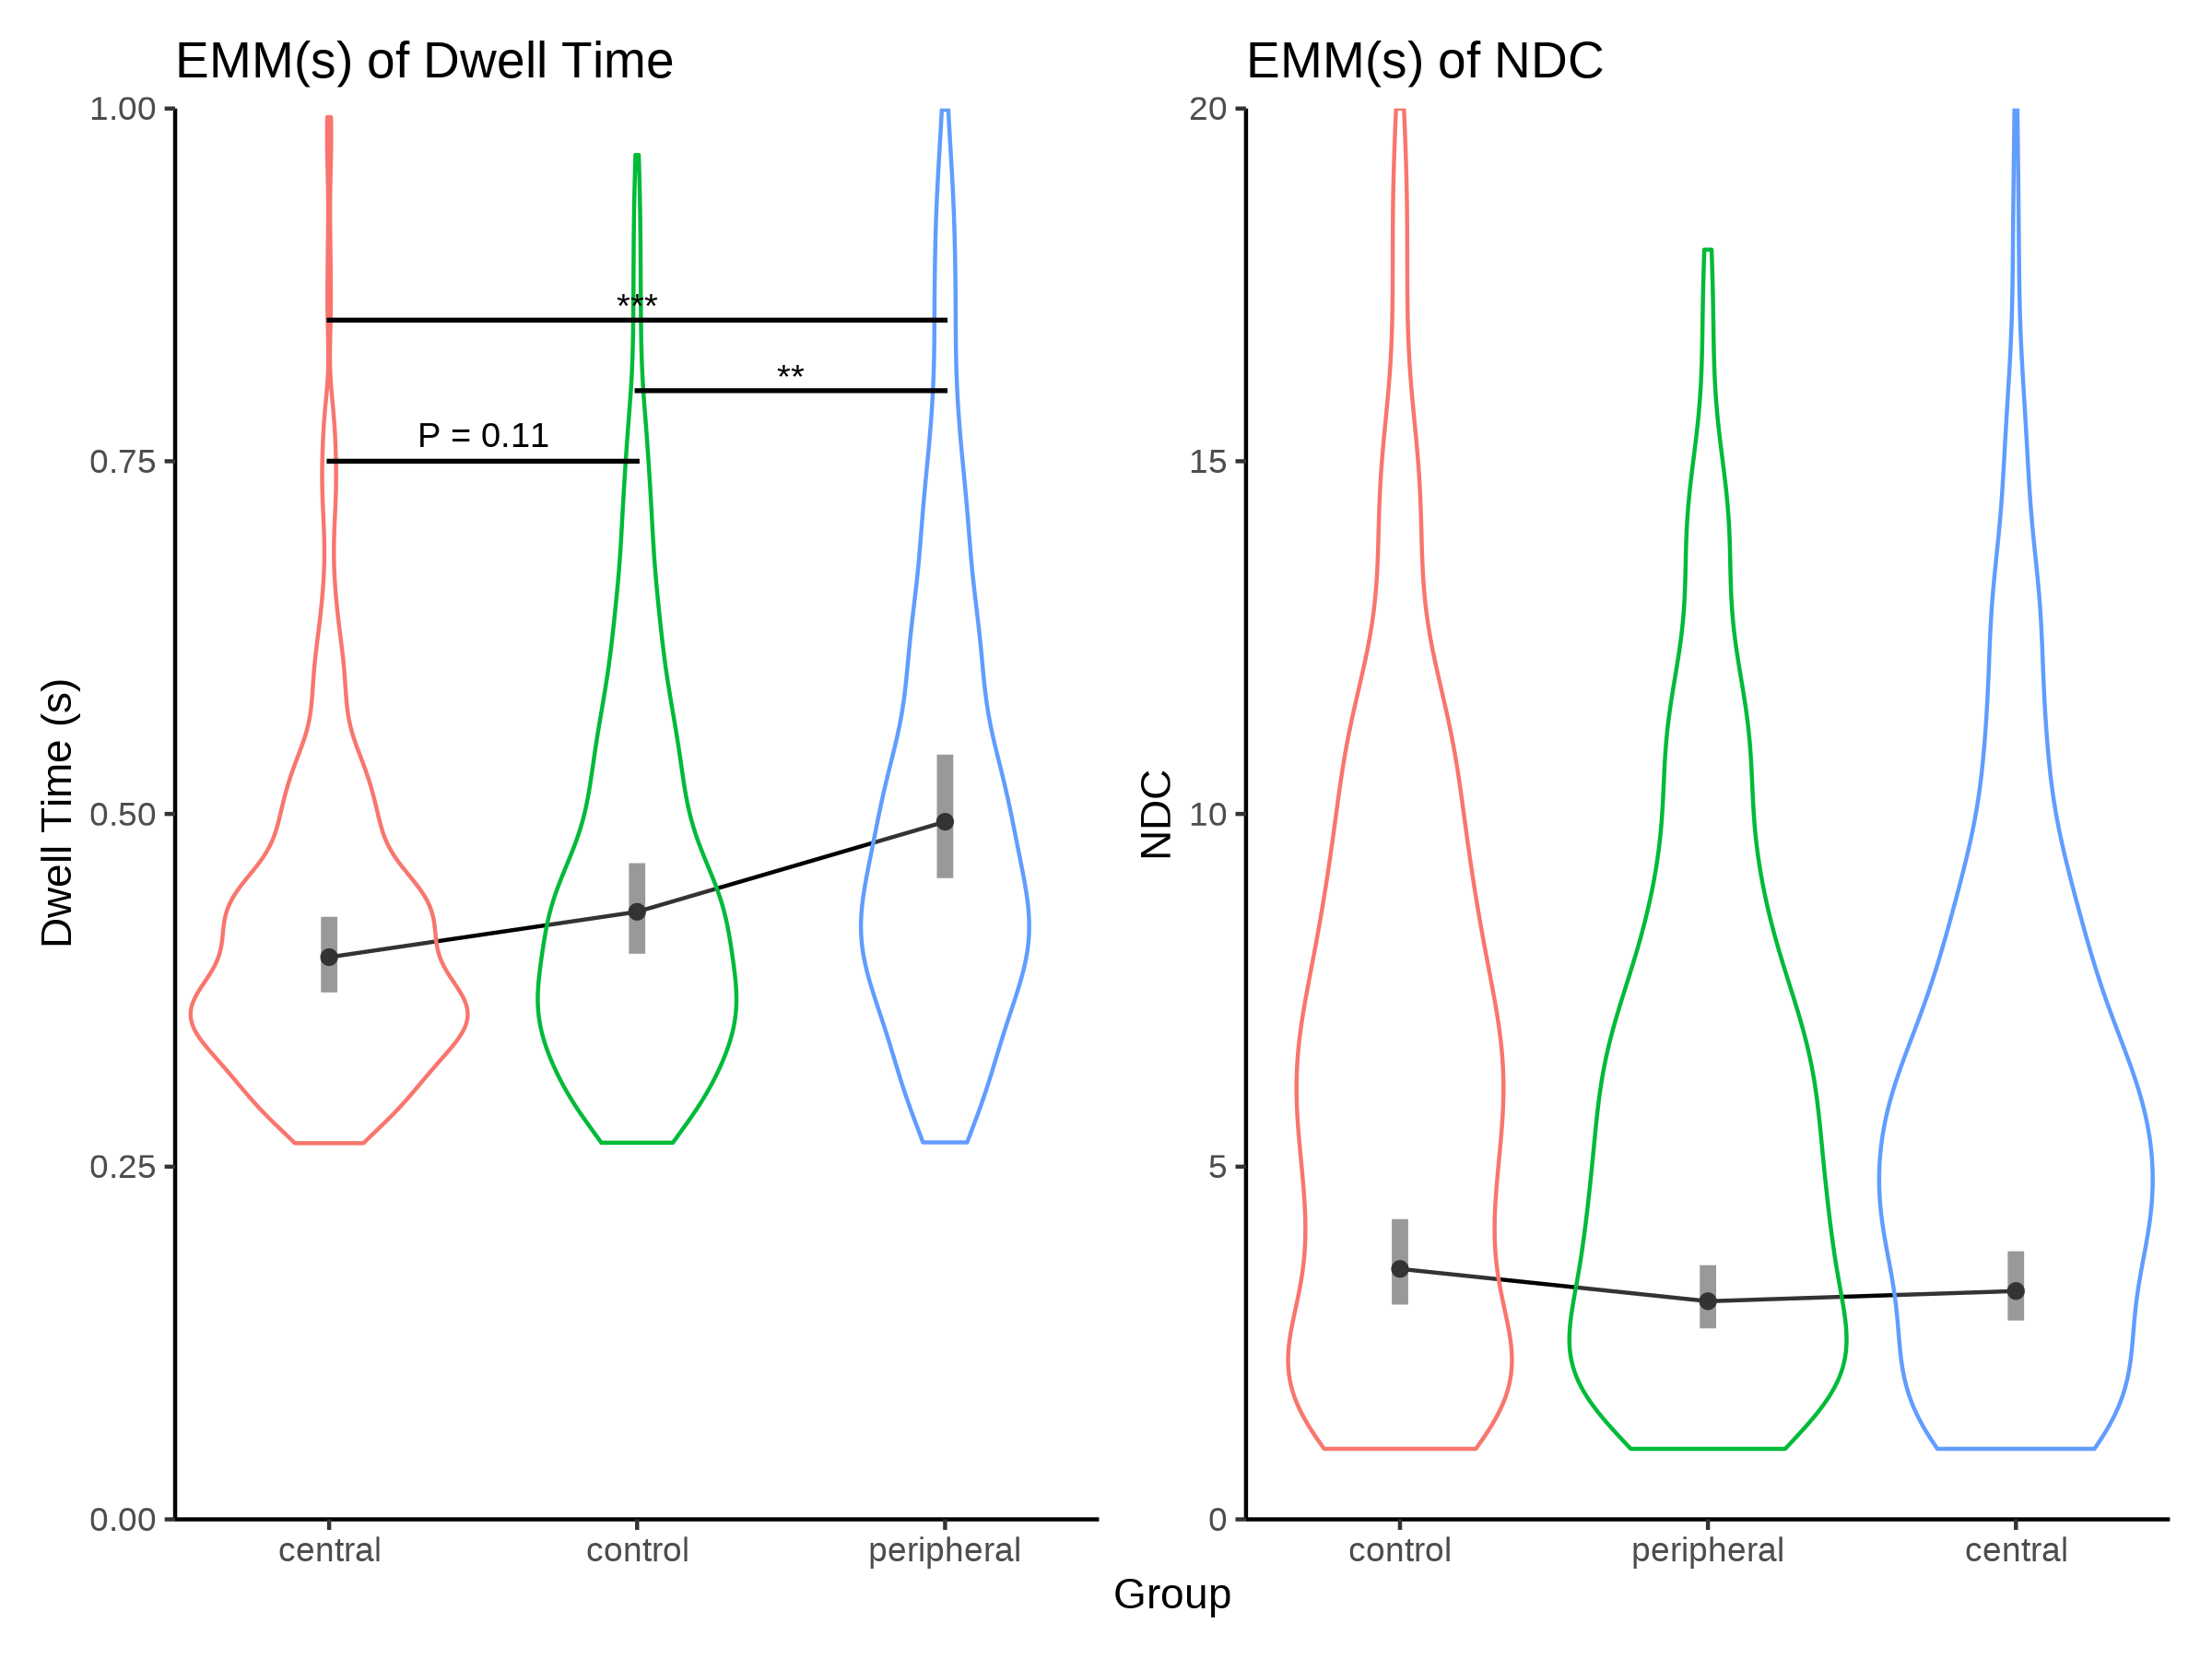

In [48]:

(dwell_time_fig + ndc_mean_fig + plot_layout(guides = 'collect', axis_titles = 'collect')) & (theme_classic() + theme(legend.position = "none"))

In [49]:
playground_table <- anova(model_0, model_inter)
playground_table
playground_table$Chisq
playground_table$`Pr(>Chisq)`

,npar,AIC,BIC,logLik,-2*log(L),Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
model_0,4,-1842.978,-1820.932,925.4889,-1850.978,NA,NA,NA
model_inter,5,-1854.464,-1826.907,932.2321,-1864.464,13.4864,1,0.0002402983


[1]      NA 13.4864

[1]           NA 0.0002402983

#### Model Summary

In [50]:
source("utils.R")

In [51]:
dwell_time_model_summaries <- get_sim_model_summary(model_0, model_inter, model_full)
node_model_summaries <- get_sim_model_summary(node_model_0, node_model_inter, node_model_full)

#### GT Table Generation

In [52]:
library(gt)

In [ ]:
dt <- tibble(
    model_name = c(
        "**LRT**",
        "***fixed effects***",
        "intercept",
        "region (inside)",
        "condition (peripheral)",
        "condition (central)",
        "***random effects***",
        "building",
        "participant",
        "observation-level<br>&nbsp;&nbsp;(distribution-specific)",
        "$R^2_{GLMM(m)}$ (%)",
        "$R^2_{GLMM(c)}$ (%)",
        "$ICC_{[Building]}$ (%)",
        "$ICC_{[Participant]}$ (%)",
        "$AIC$"
    ),
    # dwell time models
    dw_null_model = dwell_time_model_summaries$model_null,
    dw_inter_model = dwell_time_model_summaries$model_inter_summary,
    dw_full_model = dwell_time_model_summaries$model_full_summary,
    # node models
    node_null_model = node_model_summaries$model_null,
    node_inter_model = node_model_summaries$model_inter_summary,
    node_full_model = node_model_summaries$model_full_summary
)

dt %>% gt() %>% 
  tab_spanner(
    label = md("**Dwell Time Models (inverse-link)<br>Gamma Mixed Models**"),
    columns = starts_with("dw"),
    id = "dwell_time_models"
  ) %>%
  tab_spanner(
    label = md("**NDC Models (log-link)<br>Poisson Mixed Models**"),
    columns = starts_with("node")
  ) %>%
  cols_label(
    model_name = md("**Model Name**"),
    dw_null_model = md("**Null Model**"),
    dw_inter_model = md("**Intermediate Model**"),
    dw_full_model = md("**Full Model**"),
    node_null_model = md("**Null Model**"),
    node_inter_model = md("**Intermediate Model**"),
    node_full_model = md("**Full Model**")
  ) %>%
  tab_style(
    style = cell_borders(
      sides = c("right", "left"),
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_spanners(
      "dwell_time_models"
    )
  ) %>%
  tab_style(
    style = cell_borders(
      sides = "right",
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_labels(
      "dw_full_model"
    )
  ) %>%
   tab_style(
    style = cell_borders(
      sides = "right",
      color = "black",
      weight = px(2)
    ),
    locations = cells_body(
      "dw_full_model"
    )
  ) %>%
  tab_style(
    style = cell_borders(
      sides = "left",
      color = "black",
      weight = px(2)
    ),
    locations = cells_column_labels(
      "dw_null_model"
    )
  ) %>%
   tab_style(
    style = cell_borders(
      sides = "left",
      color = "black",
      weight = px(2)
    ),
    locations = cells_body(
      "dw_null_model"
    )
  ) %>%
  cols_width(everything() ~ px(200)) %>%
  fmt_markdown() %>%
  gtsave("model_summaries.html")
  #capture.output() %>% 
  #IRdisplay::display_html()
